Random Forest - Visa Denial Prediction (IT25103364)
This notebook trains a Random Forest to predict whether a PERM visa application is denied (denied = 1). It uses handover B (final_processed.csv.gz: 25 selected, scaled features) and the shared split column, so the result is comparable with the other five models. Only 6.9% of applications are denied, so accuracy is shown next to the 93.1% "always approve" baseline and the model is judged on PR-AUC, recall and F1 for the Denied class.

Rules followed (README section 5):

1.Tune on split == 'train' with the shared StratifiedKFold(5, shuffle=True, random_state=42).
2.The tuning search runs on a stratified subsample of the train rows; the final model is refit on all train rows.
3.The decision threshold is chosen from out-of-fold predictions, never from the test set.
4.split == 'test' is used once, at the end.
5.All artifacts are saved to results/models/IT25103364_RandomForest/.


1. Imports, paths and shared settings

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# --- Project paths (same layout as group_pipeline.ipynb): search upward for the repo root ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'results', 'outputs')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
MODEL_DIR = os.path.join(ROOT, 'results', 'models', 'IT25103364_RandomForest')
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Shared settings (identical in every notebook) ---
TARGET = 'denied'            # 1 = Denied, 0 = Certified / Certified-Expired
SEED = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# --- Settings for this model ---
VERSION = 'B'                # 'B' = 25 selected features (default), 'A' = all 107 features (optional variety)
TUNE_ROWS = 40_000           # stratified subsample of the TRAIN rows used for the hyperparameter search
N_ITER = 8                   # number of random hyperparameter combinations to try


def load_handover(version='B'):
    """A = all 107 features, unscaled | B = 25 selected features, scaled. Returns X_train, y_train, X_test, y_test."""
    name = {'A': 'cleaned_unscaled_allfeatures.csv.gz', 'B': 'final_processed.csv.gz'}[version]
    df = pd.read_csv(os.path.join(OUT_DIR, name))
    train, test = df[df['split'].eq('train')], df[df['split'].eq('test')]
    return (train.drop(columns=[TARGET, 'split']), train[TARGET],
            test.drop(columns=[TARGET, 'split']), test[TARGET])

## 2. Load the handover dataset

This cell loads the train and test rows with the shared `load_handover` function. The output shows the number of rows and the share of denied applications in the training rows.

In [2]:
X_train, y_train, X_test, y_test = load_handover(VERSION)
print(f'Handover {VERSION}: X_train {X_train.shape}, X_test {X_test.shape}, train denied rate {y_train.mean():.2%}')

Handover B: X_train (283879, 25), X_test (70970, 25), train denied rate 6.91%


## 3. Hyperparameter search (the varieties table)
Random Forest on 284k rows is slow, so the search runs on a stratified subsample of the **train** rows (`TUNE_ROWS`). Each of the `N_ITER` combinations is scored with the shared 5-fold `CV` on PR-AUC (`average_precision`), which suits the imbalanced target. The grid mixes tree depth, leaf size, `max_features` and two class-weighting schemes, so every row of `cv_results_` is a different variety of the model. The full table is saved to `cv_results.csv`.


In [3]:
# Stratified subsample of the TRAIN rows only (the test rows are never touched here)
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=TUNE_ROWS,
                                        stratify=y_train, random_state=SEED)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 0.5],
    'class_weight': ['balanced_subsample', {0: 1, 1: 5}],
}
search = RandomizedSearchCV(RandomForestClassifier(n_jobs=-1, random_state=SEED), param_dist,
                            n_iter=N_ITER, scoring='average_precision', cv=CV,
                            n_jobs=1, random_state=SEED, verbose=1)
t0 = time.time()
search.fit(X_tune, y_tune)
print(f'Tuning took {time.time() - t0:.0f}s')
print('Best params:', search.best_params_)
print(f'Best CV PR-AUC on the tuning subsample: {search.best_score_:.4f}')

cv_table = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
cv_table.to_csv(os.path.join(MODEL_DIR, 'cv_results.csv'), index=False)
cv_table[['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_fit_time', 'params']].round(4)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Tuning took 100s
Best params: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': {0: 1, 1: 5}}
Best CV PR-AUC on the tuning subsample: 0.4183


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
4,1,0.4183,0.0139,1.0480,"{'n_estimators': 100, 'min_samples_leaf': 5, '..."
7,2,0.4026,0.0100,2.1395,"{'n_estimators': 100, 'min_samples_leaf': 1, '..."
6,3,0.3953,0.0164,1.7215,"{'n_estimators': 200, 'min_samples_leaf': 10, ..."
2,4,0.3932,0.0180,2.1491,"{'n_estimators': 200, 'min_samples_leaf': 5, '..."
3,5,0.3889,0.0199,3.5481,"{'n_estimators': 200, 'min_samples_leaf': 20, ..."
1,6,0.3820,0.0169,4.0956,"{'n_estimators': 100, 'min_samples_leaf': 1, '..."
5,7,0.3791,0.0149,2.1564,"{'n_estimators': 100, 'min_samples_leaf': 1, '..."
0,8,0.3728,0.0212,2.2338,"{'n_estimators': 200, 'min_samples_leaf': 20, ..."


## 4. Cross-validation on the full train rows and out-of-fold threshold
This cell fits the best settings with the shared 5-fold `CV` on **all** train rows. Each train row gets an **out-of-fold** probability from a model that never saw it, using the same hyperparameters as the final model. Two things come from these predictions:

- **CV mean ± std** for PR-AUC, ROC-AUC, precision, recall and F1 on the full train rows, saved to `cv_summary.csv`.
- **The decision threshold**: the cut-off with the best F1, chosen only from out-of-fold predictions of train rows that were **not** in the tuning subsample, so the threshold shares no rows with the hyperparameter search. The test set is not used.

In [4]:
best_params = search.best_params_
rf_final = RandomForestClassifier(**best_params, n_jobs=-1, random_state=SEED)

oof = np.zeros(len(y_train))
fold_of = np.zeros(len(y_train), dtype=int)
t0 = time.time()
for k, (tr, va) in enumerate(CV.split(X_train, y_train)):
    model_k = clone(rf_final).fit(X_train.iloc[tr], y_train.iloc[tr])
    oof[va] = model_k.predict_proba(X_train.iloc[va])[:, 1]
    fold_of[va] = k
print(f'Out-of-fold predictions took {time.time() - t0:.0f}s')

# Threshold: best F1 on out-of-fold predictions of train rows NOT used for tuning
not_tuned = ~X_train.index.isin(X_tune.index)
prec, rec, thr_grid = precision_recall_curve(y_train[not_tuned], oof[not_tuned])
f1_grid = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-9, None)
THRESHOLD = float(thr_grid[np.argmax(f1_grid)])
print(f'Out-of-fold F1-optimal threshold: {THRESHOLD:.3f} (chosen on {not_tuned.sum():,} non-tuning train rows)')

# Per-fold scores and mean +/- std over the 5 folds
y_arr = y_train.to_numpy()
rows = []
for k in range(CV.get_n_splits()):
    m = fold_of == k
    pred = (oof[m] >= THRESHOLD).astype(int)
    rows.append({'fold': k + 1,
                 'PR-AUC': average_precision_score(y_arr[m], oof[m]),
                 'ROC-AUC': roc_auc_score(y_arr[m], oof[m]),
                 'Precision': precision_score(y_arr[m], pred),
                 'Recall': recall_score(y_arr[m], pred),
                 'F1': f1_score(y_arr[m], pred)})
cv_folds = pd.DataFrame(rows)
metrics = ['PR-AUC', 'ROC-AUC', 'Precision', 'Recall', 'F1']
cv_summary = pd.DataFrame({'mean': cv_folds[metrics].mean(), 'std': cv_folds[metrics].std()})
cv_summary['mean +/- std'] = cv_summary.apply(lambda r: f"{r['mean']:.4f} +/- {r['std']:.4f}", axis=1)
cv_summary.to_csv(os.path.join(MODEL_DIR, 'cv_summary.csv'))
cv_folds.to_csv(os.path.join(MODEL_DIR, 'cv_folds.csv'), index=False)
cv_summary.round(4)

Out-of-fold predictions took 78s
Out-of-fold F1-optimal threshold: 0.518 (chosen on 243,879 non-tuning train rows)


,mean,std,mean +/- std
PR-AUC,0.4722,0.0106,0.4722 +/- 0.0106
ROC-AUC,0.8441,0.0036,0.8441 +/- 0.0036
Precision,0.5060,0.0127,0.5060 +/- 0.0127
Recall,0.3993,0.0105,0.3993 +/- 0.0105
F1,0.4464,0.0114,0.4464 +/- 0.0114


## 5. Final model and one-time test evaluation
This cell refits the best settings on **all** train rows and evaluates on the shared test set once, at the out-of-fold threshold and at the default 0.5. Precision, recall and F1 are for the Denied class. Accuracy is printed next to the "always approve" baseline, because the baseline is already about 93.1%. Everything is saved to `test_results.json`.

In [5]:
rf_final.fit(X_train, y_train)
proba = rf_final.predict_proba(X_test)[:, 1]
baseline_acc = 1 - y_test.mean()

test_rows, test_json = [], {}
for label, cut in [('threshold 0.5', 0.5), (f'OOF threshold {THRESHOLD:.3f}', THRESHOLD)]:
    pred = (proba >= cut).astype(int)
    cm = confusion_matrix(y_test, pred)
    test_rows.append({'setting': label,
                      'Precision (Denied)': precision_score(y_test, pred),
                      'Recall (Denied)': recall_score(y_test, pred),
                      'F1 (Denied)': f1_score(y_test, pred),
                      'Macro-F1': f1_score(y_test, pred, average='macro'),
                      'Accuracy': accuracy_score(y_test, pred),
                      'Always-approve accuracy': baseline_acc})
    test_json[label] = {'threshold': float(cut), 'confusion_matrix': cm.tolist(),
                        **{k: float(v) for k, v in test_rows[-1].items() if k != 'setting'}}
test_json['PR-AUC'] = float(average_precision_score(y_test, proba))
test_json['ROC-AUC'] = float(roc_auc_score(y_test, proba))
test_json['best_params'] = {k: str(v) for k, v in best_params.items()}
test_json['threshold_source'] = 'out-of-fold predictions on train rows not used for tuning'
with open(os.path.join(MODEL_DIR, 'test_results.json'), 'w') as f:
    json.dump(test_json, f, indent=2)

print(f"Test PR-AUC {test_json['PR-AUC']:.4f} (random baseline {y_test.mean():.4f}) | ROC-AUC {test_json['ROC-AUC']:.4f}")
pd.DataFrame(test_rows).round(4)

Test PR-AUC 0.4645 (random baseline 0.0691) | ROC-AUC 0.8432


,setting,Precision (Denied),Recall (Denied),F1 (Denied),Macro-F1,Accuracy,Always-approve accuracy
0,threshold 0.5,0.4699,0.4059,0.4356,0.6984,0.9273,0.9309
1,OOF threshold 0.518,0.4986,0.3880,0.4364,0.6997,0.9307,0.9309


## 6. Feature importance, PR curve and confusion matrix
The left chart shows the 15 features the forest relies on most (impurity importance: how much a feature is used for splits, not whether it raises or lowers the chance of denial). The middle chart is the precision-recall curve on the test set against the 6.9% random baseline. The right chart is the confusion matrix at the out-of-fold threshold. The figure is shown here and saved to the model folder.


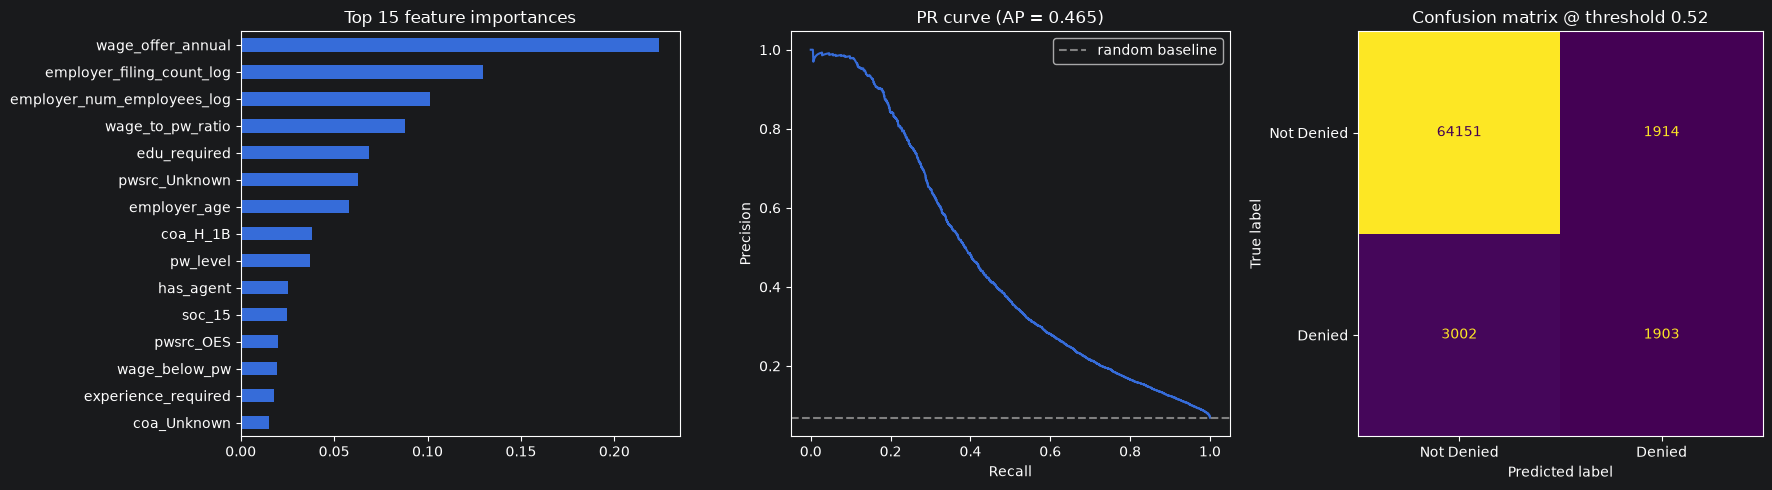

wage_offer_annual             0.2238
employer_filing_count_log     0.1296
employer_num_employees_log    0.1012
wage_to_pw_ratio              0.0880
edu_required                  0.0689
pwsrc_Unknown                 0.0626
employer_age                  0.0578
coa_H_1B                      0.0383
pw_level                      0.0369
has_agent                     0.0253
dtype: float64

In [6]:
imp = pd.Series(rf_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)
imp.to_csv(os.path.join(MODEL_DIR, 'feature_importance.csv'), header=['importance'])

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
imp.head(15)[::-1].plot.barh(ax=ax[0], title='Top 15 feature importances')
p_curve, r_curve, _ = precision_recall_curve(y_test, proba)
ax[1].plot(r_curve, p_curve)
ax[1].axhline(y_test.mean(), ls='--', c='grey', label='random baseline')
ax[1].set(xlabel='Recall', ylabel='Precision', title=f"PR curve (AP = {test_json['PR-AUC']:.3f})")
ax[1].legend()
ConfusionMatrixDisplay(confusion_matrix(y_test, (proba >= THRESHOLD).astype(int)),
                       display_labels=['Not Denied', 'Denied']).plot(ax=ax[2], colorbar=False)
ax[2].set_title(f'Confusion matrix @ threshold {THRESHOLD:.2f}')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'random_forest_results.png'), dpi=120)
plt.show()
imp.head(10).round(4)